<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; 고객 성공 분석팀</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">고객 이탈 근본 원인 분석</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">중견기업 B2B SaaS 고객유지 검토를 위한 PROC FISHBONE 원인-결과 다이어그램</div>
</div>

## 요약

이 분석은 급증한 SaaS 고객 이탈의 근본 원인 동인들을 구조화된 원인-결과(이시카와) 다이어그램으로 정리합니다. 중견기업 B2B 세그먼트는 목표치 8%에 비해 연 18% 수준으로 이탈하고 있습니다. 이탈 설문, 고객 성공팀 인터뷰, 코호트 기여도 분석에서 도출한 20개의 근본 원인 조사 결과를 6개의 원인 범주로 그룹화하여 `PROC FISHBONE`으로 27개 노드(결과 1개, 범주 뼈대 6개, 세부 원인 20개)로 렌더링합니다.

보조 `PROC MEANS` 분석은 귀속 가능한 이탈이 어디에 집중되는지 보여줍니다. **제품(Product)**이 가장 많은 조사 결과를 차지하며(원인 5개, 총 영향 점수 48.1점), 그다음은 **가격(Pricing)**(원인 4개, 42.3점)과 **지원(Support)**(원인 4개, 40.2점)입니다. 원인 하나당 평균 영향도로 보면 **경쟁(Competition)**이 가장 심각한 범주이며(평균 11.8점), 개별 조사 결과 중 영향도가 가장 높은 것은 사전 경고 없는 **가격(Pricing)** 갱신 인상입니다(14.2점). `PROC SGPLOT` 파레토 뷰는 모든 개별 원인의 순위를 매겨 경영진이 어느 뼈대부터 조치해야 할지 파악할 수 있게 합니다. 이 산출물은 고객 성공팀의 분기별 고객유지 검토 자료로 활용됩니다.


## 데이터 소스

| 소스 | 설명 | 레코드 수 |
|--------|-------------|--------|
| WORK.CHURN_RCA | 이탈 설문 분석과 CS팀 회고에서 통합한 고객 이탈 근본 원인 조사 결과. 각 행은 범주, 근거, 추정 이탈 영향 비율을 포함한 하나의 원인 | 20 |


---

In [1]:
/* --------------------------------------------------------
   고객 이탈 근본 원인 조사 결과(RCA)
   SaaS 플랫폼, B2B 중견기업 세그먼트.
   각 행: 원인 범주, 구체적인 원인, 근거가 되는
   세부원인/증거 메모, 이탈 설문 및 코호트 기여도
   분석을 통해 추정한 이탈 귀속 비율
   -------------------------------------------------------- */
데이터 work.churn_rca;
    INFILE 자료 dlm='|' dsd truncover;
    입력 category :$20. cause :$120. subcause :$150. churn_impact_pct;
    자료;
제품|엔터프라이즈 경쟁사 대비 핵심 기능 격차|이탈 설문의 34%에서 대량 내보내기 및 API 호출 제한 언급|12.4
제품|보고 기능이 제한적|스탠다드 요금제에 맞춤형 대시보드 빌더 없음|9.8
제품|모바일 앱 기능이 웹 대비 뒤처짐|모바일 전용 사용자가 완료할 수 없는 핵심 워크플로우 3가지|8.2
제품|사전 공지 없는 잦은 UI 변경|분기별 UI 개편으로 파워 유저 업무 차질|7.6
제품|연동 마켓플레이스 공백|Salesforce 및 HubSpot 네이티브 커넥터 부재|10.1
가격|사전 통보 없는 갱신 가격 인상|30일 전 통보로 MRR 18% 인상|14.2
가격|좌석당 과금제가 팀 성장에 불리하게 작용|팀 규모가 10명에서 20명으로 늘면 비용이 두 배|11.3
가격|초기 할인 갱신 불가|첫 갱신 시 가격 충격|9.7
가격|다년 계약 인센티브 없음|연간 요금이 월간 요금과 동일|7.1
지원|최초 응답 시간이 24시간 초과|요금제 기준 응답 시간은 4시간|10.8
지원|주말 지원 품질 격차|해외 대응 인력의 제품 지식 부족|9.3
지원|엔터프라이즈 미만 요금제에 전담 CSM 없음|중견기업 고객에 지정 담당자 없음|11.5
지원|고객에게 에스컬레이션 경로가 불명확|이탈 고객의 38%가 에스컬레이션 절차 혼란을 언급|8.6
온보딩|가치 실현까지 90일 초과|판매 전 구축 복잡성 미고지|12.9
온보딩|셀프서비스 문서가 오래됨|마지막 업데이트 11개월 전|8.1
온보딩|신규 기능 인앱 가이드 투어 없음|6개월 시점 기능 채택률 30% 미만|9.4
경쟁|경쟁사가 30% 낮은 가격 제시|주요 고객 3곳이 특정 경쟁사를 지목|13.1
경쟁|경쟁사가 무제한 좌석 요금제 제공|성장하는 팀에 좌석당 불이익 해소|10.6
관계|임원 스폰서 이탈 관리 미흡|챔피언 퇴사 후 재참여 프로그램 부재|11.7
관계|QBR 주기가 연 1회로 축소|18개월 전 CS팀 인력 감축|9.2
;
실행;




NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   기준 확인: RCA 범주별 이탈 영향 집중도.
   합계는 귀속 가능한 이탈이 어디에 몰려 있는지 보여주고,
   최댓값은 각 범주에서 가장 심각한 단일 원인을 알려줍니다.
   -------------------------------------------------------- */
처리 평균 데이터=work.churn_rca n sum mean MAX maxdec=1;
    분류 category;
    변수 churn_impact_pct;
    라벨 category='원인 범주' churn_impact_pct='이탈 영향률 (%)';
    제목 '카테고리별 고객 이탈 원인분석(RCA) 영향률';
실행;



                                               카테고리별 고객 이탈 원인분석(RCA) 영향률                                                

                                                  The MEANS Procedure

                               Analysis Variable : churn_impact_pct 이탈 영향률 (%)

        원인 범주                  N Obs            Sum           Mean        Maximum
        -------------------------------------------------------------------------
        가격                         4           42.3           10.6           14.2
        경쟁                         2           23.7           11.8           13.1
        관계                         2           20.9           10.4           11.7
        온보딩                        3           30.4           10.1           12.9
        제품                         5           48.1            9.6           12.4
        지원                         4           40.2           10.1           11.5
        ---------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                               카테고리별 고객 이탈 원인분석(RCA) 영향률                                                




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


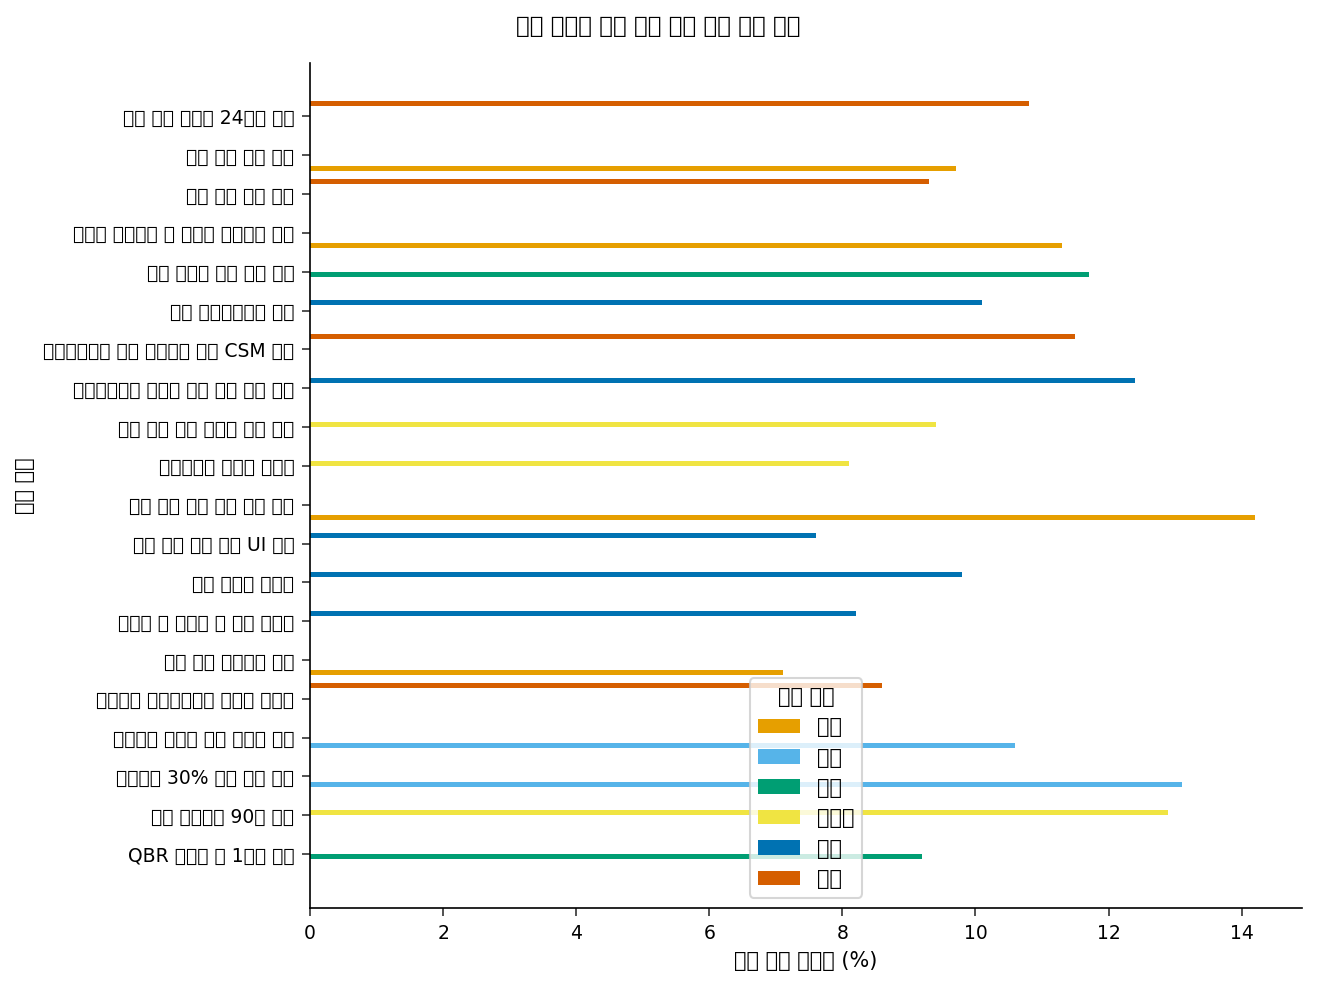

In [3]:
/* --------------------------------------------------------
   파레토 뷰: 추정 이탈 영향도로 순위를 매긴 개별 근본
   원인을 범주별로 색상 구분. 어느 뼈대가 가장 중요한지
   정량화하여 피시본 다이어그램을 보완합니다.
   -------------------------------------------------------- */
처리 정렬 데이터=work.churn_rca;
    기준 DESCENDING churn_impact_pct;
실행;

처리 SGPLOT 데이터=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS label='추정 이탈 영향도 (%)';
    YAXIS label='근본 원인' discreteorder=data;
    keylegend / title='원인 범주' position=bottom;
    제목 '추정 영향도 기준 고객 이탈 근본 원인 순위';
실행;



---

### 원인-결과(이시카와) 다이어그램

`PROC FISHBONE`은 `WORK.CHURN_RCA`로부터 직접 다이어그램을 만듭니다. 서로 다른 각 `category`는 중심 축에서 뻗어 나가는 주요 뼈대가 되고, 개별 `cause` 조사 결과는 세부 원인으로 해당 범주 뼈대에 매달립니다. 이 절차는 아래에 전체 원인-결과 구조 — 맨 앞의 결과, 6개의 범주 뼈대, 각 뼈대 아래로 그룹화된 모든 세부 원인 — 를 출력하고, 대응하는 피시본 그래픽을 디스크에 기록합니다. 위의 순위별 파레토 차트는 이 뼈대들 중 어느 것이 가장 많은 귀속 이탈을 차지하는지 정량화하는 짝을 이루는 뷰입니다.


In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: 고객 이탈 원인-결과 다이어그램.
   다이어그램은 WORK.CHURN_RCA로부터 직접 구동되므로,
   6개의 원인 범주와 그 원인들은 위에서 분석한 조사
   결과와 정확히 일치합니다. CATEGORY가 주요 뼈대를
   이루고, CAUSE가 각 뼈대의 세부 원인으로 매달립니다.
   -------------------------------------------------------- */
처리 fishbone 데이터=work.churn_rca;
    cause category / subcause=cause;
    effect '고객 이탈 급증 (연 18% vs 목표 8%)';
    제목 '고객 이탈 근본 원인 분석 - 중견기업 세그먼트';
    footnote '출처: 이탈 설문, CS팀 인터뷰, 코호트 기여도 분석';
실행;



                                               카테고리별 고객 이탈 원인분석(RCA) 영향률                                                


                    고객 이탈 근본 원인 분석 - 중견기업 세그먼트
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] 고객 이탈 급증 (연 18% vs 목표 8%)
    [CAUSE] 가격 (top)
      [SUB] 사전 통보 없는 갱신 가격 인상
      [SUB] 좌석당 과금제가 팀 성장에 불리하게 작용
      [SUB] 초기 할인 갱신 불가
      [SUB] 다년 계약 인센티브 없음
    [CAUSE] 경쟁 (top)
      [SUB] 경쟁사가 30% 낮은 가격 제시
      [SUB] 경쟁사가 무제한 좌석 요금제 제공
    [CAUSE] 온보딩 (top)
      [SUB] 가치 실현까지 90일 초과
      [SUB] 신규 기능 인앱 가이드 투어 없음
      [SUB] 셀프서비스 문서가 오래됨
    [CAUSE] 제품 (bottom)
      [SUB] 엔터프라이즈 경쟁사 대비 핵심 기능 격차
      [SUB] 연동 마켓플레이스 공백
      [SUB] 보고 기능이 제한적
      [SUB] 모바일 앱 기능이 웹 대비 뒤처짐
      [SUB] 사전 공지 없는 잦은 UI 변경
    [CAUSE] 관계 (bottom)
      [SUB] 임원 스폰서 이탈 관리 미흡
      [SUB] QBR 주기가 연 1회로 축소
    [CAUSE] 지원 (bottom)
      [SUB] 엔터프라이즈 미만 요금제에 전담 CSM 없음
      [SUB] 최초 응답 시간이 24시간 초과
      [SUB] 주말 지원 품질 격차
      [SUB] 고객에게 에스컬레이션 경로가 불명확




NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### 해석

원인-결과 구조와 범주별 `PROC MEANS` 수치는 경영진에게 소수의 고효과 조치를 알려줍니다. 가장 영향도가 높은 두 개별 원인 — 사전 경고 없는 **가격(Pricing)** 갱신 인상(14.2)과 경쟁사가 30% 낮은 가격에 동등한 역량을 제공한다는 **경쟁(Competition)** 조사 결과(13.1) — 은 모두 제품이 아닌 상업적 문제로, 가격 투명성과 경쟁 포지셔닝이 가장 시급한 단기 지렛대임을 시사합니다. 90일을 초과하는 **온보딩(Onboarding)** 가치 실현 기간(12.9)은 서비스 측면에서 가장 큰 조사 결과이며 판매 전 기대치 설정과 직결됩니다.

건수로 보면 **제품(Product)**이 다이어그램을 지배하지만(20건 중 5건, 총 영향 점수 48.1점), 개별 조사 결과의 크기는(평균 9.6점) **경쟁(Competition)**(평균 11.8점)이나 **가격(Pricing)**(평균 10.6점)보다 작습니다 — 제품 관련 문제가 많다고 해서 자동으로 최우선 순위가 되는 것은 아니라는 점을 일깨워 줍니다. **관계(Relationship)** 뼈대(임원 스폰서 이탈과 QBR 주기 축소, 합산 20.9점)는 제품이나 가격에 투자하지 않고도 CS팀이 이번 분기 내에 실행할 수 있는 프로세스 변경을 나타내며, 측정 가능한 고객유지 개선을 위한 가장 빠른 경로를 제공합니다. 파레토 차트의 전체 순위 목록을 통해 경영진은 범주 크기가 아니라 추정 영향도 순으로 개입 순서를 정할 수 있습니다.


---

In [5]:
/* --------------------------------------------------------
   전략 검토 자료를 위한 이탈 RCA 조사 결과 내보내기
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
실행;



NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>